In [39]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
from pathlib import Path
import netCDF4  
import time
import utils as u

import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *

In [63]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

domain='MARMer'

### MAR

In [3]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRa.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [4]:
print('Mera domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

Mera domain
lon min 81.71114 lon max 90.25671
lat min 25.85994 lat max 31.11629


In [18]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRa/spin2/work/monthly/'
SourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'

In [19]:
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_GRa_2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ZTQLEV=0).TTZ.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

dsF = dsF.sel(time=slice("2000-01-01", "2020-12-31"))

model1='MAR'
res1=str('5kmx5km')

### ERA5 

In [10]:
folder_era5='/bettik/PROJECTS/pr-regional-climate/fainx/era5/'
tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRa_t2m.nc').t2m.load()-273.15

tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

tmp_era5 = tmp_era5.sel(time=slice("2000-01-01", "2020-12-31"))

model2='ERA5'
res2=str('31kmx31km')

### ERA5-land

In [22]:
folder_era5land='/bettik/PROJECTS/pr-regional-climate/fainx/era5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRa_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

tmp_era5land = tmp_era5land.sel(time=slice("2000-01-01", "2020-12-31"))

model3='ERA5-Land'
res3=str('0.1°x0.1°')

### CRU

In [52]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

model4='CRU'
res4=str('0.5°x0.5°')

### HARv2

In [64]:
folder_HARv2='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
tmp_HARv2 = xr.open_mfdataset(folder_HARv2 + 'HARv2_mon_d10km_d_2d_t2_1980-2023.nc').t2.load()-273.15
tmp_HARv2= tmp_HARv2.sel(time=slice("2000-01-01", "2020-12-31"))

def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
      #  print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

tmp_HARv2=xy_sel_dom(tmp_HARv2,domain)

model5='HARv2'
res5=str('10kmx10km')

In [65]:
modelList=[model1,model2,model3,model4,model5]
resList=[res1,res2,res3,res4,res5]
print(modelList)
print(resList)

['MAR', 'ERA5', 'ERA5-Land', 'CRU', 'HARv2']
['5kmx5km', '31kmx31km', '0.1°x0.1°', '0.5°x0.5°', '10kmx10km']


In [66]:
dsList=[dsF,tmp_era5, tmp_era5land, tmp_cru, tmp_HARv2]

In [67]:
avgList=[]
for i,elem in enumerate(dsList):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [4]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='west_east').mean(dim='south_north')
    avgList.append(avg0)


0
MAR 5kmx5km
1
ERA5 31kmx31km
2
ERA5-Land 0.1°x0.1°
3
CRU 0.5°x0.5°
4
HARv2 10kmx10km


In [68]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

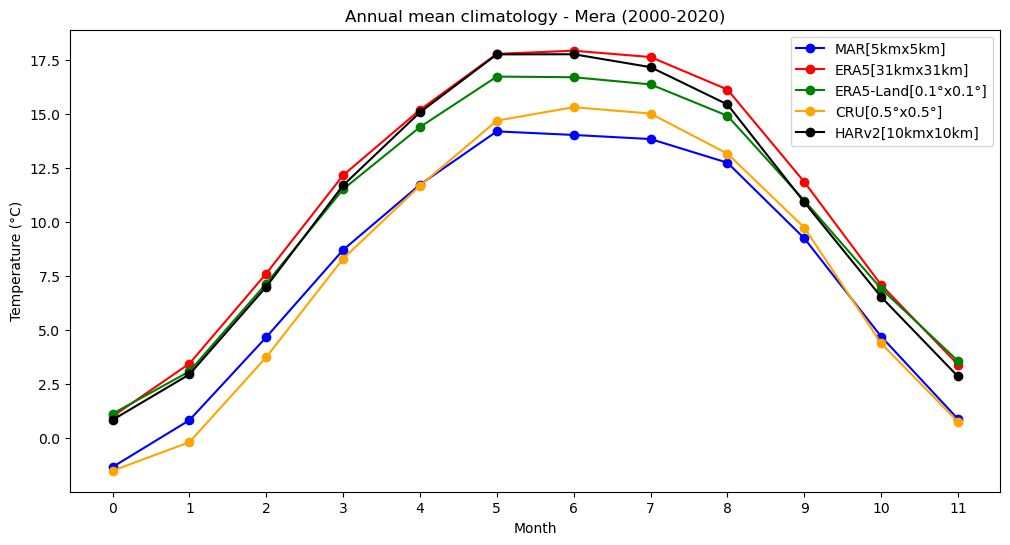

In [69]:
title="Annual mean climatology - Mera (2000-2020)"

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')
ax.plot(xmonths, annualCycleList[4], 'black',linestyle='-',marker='o',label=modelList[4]+'['+ resList[4]+']')


ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig('AnnualClimato_Fed.png',format='png')
plt.show()